<a href="https://colab.research.google.com/github/AlexBronte/mentor/blob/master/%D0%9F%D1%80%D0%B5%D0%B4%D1%81%D0%BA%D0%B0%D0%B7%D0%B0%D0%BD%D0%B8%D0%B5_%D1%86%D0%B5%D0%BD%D1%8B_%D0%BD%D0%B0_%D0%B6%D0%B8%D0%BB%D1%8C%D0%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Предсказание цены жилья

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving test.csv to test.csv
Saving train.csv to train.csv


In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, f1_score, r2_score, accuracy_score
import matplotlib.pyplot as plt

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')



In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

В данных есть признаки с большим колличеством пропусков (**более 50% данных**) ,целесообразнее будет удалить их

## Предобработка данных

In [ ]:
threshold = 0.4

missing_ratio_train = train.isna().mean()

columns_to_drop_train = missing_ratio_train[missing_ratio_train > threshold].index.tolist()

train_cleaned = train.drop(columns=columns_to_drop_train)

print(f"Колличество удаленных столбцов:{len(columns_to_drop_train)}")
print(f'Удаленные столбцы:{columns_to_drop_train}')

Колличество удаленных столбцов:6
Удаленные столбцы:['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']


In [ ]:
missing_ratio_test = test.isna().mean()

columns_to_drop_test = missing_ratio_test[missing_ratio_test > 0.5].index.tolist()

test_cleaned = test.drop(columns=columns_to_drop_test, axis=1)

print(f"Колличество удаленных столбцов:{len(columns_to_drop_test)}")
print(f'Удаленные столбцы:{columns_to_drop_test}')

Колличество удаленных столбцов:6
Удаленные столбцы:['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']


Также проверим данные на дубликаты и удалим их

In [ ]:
train_cleaned.duplicated().sum()

np.int64(0)

In [ ]:
test_cleaned.duplicated().sum()

np.int64(0)

Приведем названия столбцов к нижнему регистру

In [ ]:
test_cleaned.columns = test_cleaned.columns.str.lower()
train_cleaned.columns = train_cleaned.columns.str.lower()

Заполним пропуски в данных. В категориальных поставим заглушку 'unknown' в численных заменим медианой

In [ ]:
cat_columns_test = test_cleaned.select_dtypes(include=['object']).columns.tolist()
num_columns_test = test_cleaned.select_dtypes(exclude=['object']).columns.tolist()

cat_columns_train = train_cleaned.select_dtypes(include=['object']).columns.tolist()
num_columns_train = train_cleaned.select_dtypes(exclude=['object']).columns.tolist()


In [ ]:
test_cleaned[cat_columns_test] = test_cleaned[cat_columns_test].apply(lambda col : col.fillna('unknown'))
test_cleaned[num_columns_test] = test_cleaned[num_columns_test].apply(lambda col : col.fillna(col.median()))

In [ ]:
train_cleaned[cat_columns_train] = train_cleaned[cat_columns_train].apply(lambda col : col.fillna('unknown'))
train_cleaned[num_columns_train] = train_cleaned[num_columns_train].apply(lambda col : col.fillna(col.median()))

Проверим категориальные признаки на наличие ошибок в названиях

In [ ]:
for col in cat_columns_test:
  print(test_cleaned[col].unique())

['RH' 'RL' 'RM' 'FV' 'C (all)' 'unknown']
['Pave' 'Grvl']
['Reg' 'IR1' 'IR2' 'IR3']
['Lvl' 'HLS' 'Bnk' 'Low']
['AllPub' 'unknown']
['Inside' 'Corner' 'FR2' 'CulDSac' 'FR3']
['Gtl' 'Mod' 'Sev']
['NAmes' 'Gilbert' 'StoneBr' 'BrDale' 'NPkVill' 'NridgHt' 'Blmngtn'
 'NoRidge' 'Somerst' 'SawyerW' 'Sawyer' 'NWAmes' 'OldTown' 'BrkSide'
 'ClearCr' 'SWISU' 'Edwards' 'CollgCr' 'Crawfor' 'Blueste' 'IDOTRR'
 'Mitchel' 'Timber' 'MeadowV' 'Veenker']
['Feedr' 'Norm' 'PosN' 'RRNe' 'Artery' 'RRNn' 'PosA' 'RRAn' 'RRAe']
['Norm' 'Feedr' 'PosA' 'PosN' 'Artery']
['1Fam' 'TwnhsE' 'Twnhs' 'Duplex' '2fmCon']
['1Story' '2Story' 'SLvl' '1.5Fin' 'SFoyer' '2.5Unf' '1.5Unf']
['Gable' 'Hip' 'Gambrel' 'Flat' 'Mansard' 'Shed']
['CompShg' 'Tar&Grv' 'WdShake' 'WdShngl']
['VinylSd' 'Wd Sdng' 'HdBoard' 'Plywood' 'MetalSd' 'CemntBd' 'WdShing'
 'BrkFace' 'AsbShng' 'BrkComm' 'Stucco' 'AsphShn' 'unknown' 'CBlock']
['VinylSd' 'Wd Sdng' 'HdBoard' 'Plywood' 'MetalSd' 'Brk Cmn' 'CmentBd'
 'ImStucc' 'Wd Shng' 'AsbShng' 'Stucco' 'C

In [ ]:
for col in cat_columns_train:
  print(train_cleaned[col].unique())

['RL' 'RM' 'C (all)' 'FV' 'RH']
['Pave' 'Grvl']
['Reg' 'IR1' 'IR2' 'IR3']
['Lvl' 'Bnk' 'Low' 'HLS']
['AllPub' 'NoSeWa']
['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3']
['Gtl' 'Mod' 'Sev']
['CollgCr' 'Veenker' 'Crawfor' 'NoRidge' 'Mitchel' 'Somerst' 'NWAmes'
 'OldTown' 'BrkSide' 'Sawyer' 'NridgHt' 'NAmes' 'SawyerW' 'IDOTRR'
 'MeadowV' 'Edwards' 'Timber' 'Gilbert' 'StoneBr' 'ClearCr' 'NPkVill'
 'Blmngtn' 'BrDale' 'SWISU' 'Blueste']
['Norm' 'Feedr' 'PosN' 'Artery' 'RRAe' 'RRNn' 'RRAn' 'PosA' 'RRNe']
['Norm' 'Artery' 'RRNn' 'Feedr' 'PosN' 'PosA' 'RRAn' 'RRAe']
['1Fam' '2fmCon' 'Duplex' 'TwnhsE' 'Twnhs']
['2Story' '1Story' '1.5Fin' '1.5Unf' 'SFoyer' 'SLvl' '2.5Unf' '2.5Fin']
['Gable' 'Hip' 'Gambrel' 'Mansard' 'Flat' 'Shed']
['CompShg' 'WdShngl' 'Metal' 'WdShake' 'Membran' 'Tar&Grv' 'Roll'
 'ClyTile']
['VinylSd' 'MetalSd' 'Wd Sdng' 'HdBoard' 'BrkFace' 'WdShing' 'CemntBd'
 'Plywood' 'AsbShng' 'Stucco' 'BrkComm' 'AsphShn' 'Stone' 'ImStucc'
 'CBlock']
['VinylSd' 'MetalSd' 'Wd Shng' 'HdBoard' 'Plywood

Проверим распределение целевого признака

In [ ]:
train_cleaned.columns

Index(['id', 'mssubclass', 'mszoning', 'lotfrontage', 'lotarea', 'street',
       'lotshape', 'landcontour', 'utilities', 'lotconfig', 'landslope',
       'neighborhood', 'condition1', 'condition2', 'bldgtype', 'housestyle',
       'overallqual', 'overallcond', 'yearbuilt', 'yearremodadd', 'roofstyle',
       'roofmatl', 'exterior1st', 'exterior2nd', 'masvnrarea', 'exterqual',
       'extercond', 'foundation', 'bsmtqual', 'bsmtcond', 'bsmtexposure',
       'bsmtfintype1', 'bsmtfinsf1', 'bsmtfintype2', 'bsmtfinsf2', 'bsmtunfsf',
       'totalbsmtsf', 'heating', 'heatingqc', 'centralair', 'electrical',
       '1stflrsf', '2ndflrsf', 'lowqualfinsf', 'grlivarea', 'bsmtfullbath',
       'bsmthalfbath', 'fullbath', 'halfbath', 'bedroomabvgr', 'kitchenabvgr',
       'kitchenqual', 'totrmsabvgrd', 'functional', 'fireplaces', 'garagetype',
       'garageyrblt', 'garagefinish', 'garagecars', 'garagearea', 'garagequal',
       'garagecond', 'paveddrive', 'wooddecksf', 'openporchsf',
       'enclo

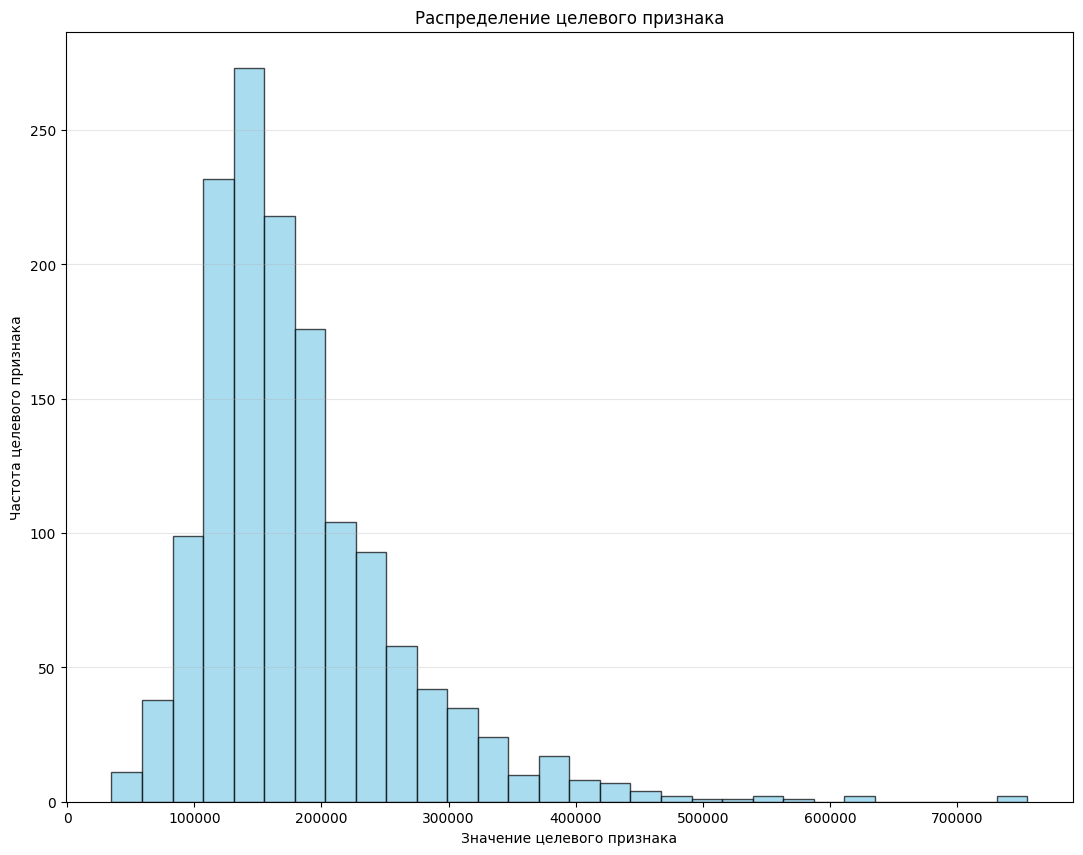

In [ ]:
plt.figure(figsize=(13,10))
plt.hist(train_cleaned['saleprice'], bins=30, alpha=0.7, color='skyblue',edgecolor='black')
plt.title('Распределение целевого признака')
plt.xlabel('Значение целевого признака')
plt.ylabel('Частота целевого признака')
plt.grid(axis='y',alpha=0.3)
plt.show()

В данных имеются аномальные значения


## EDA Анализ

Проверим распределение целевого признака с другими численными признаками

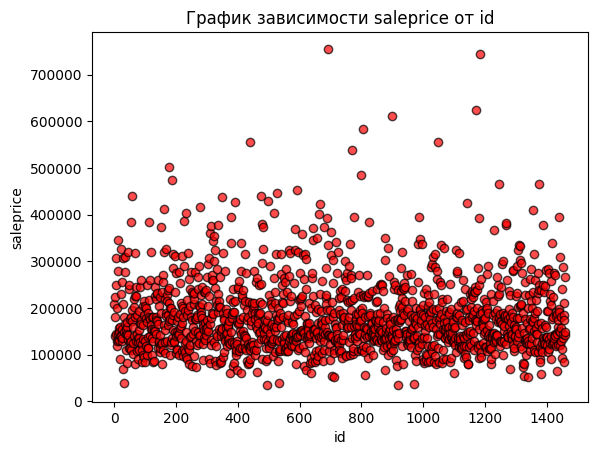

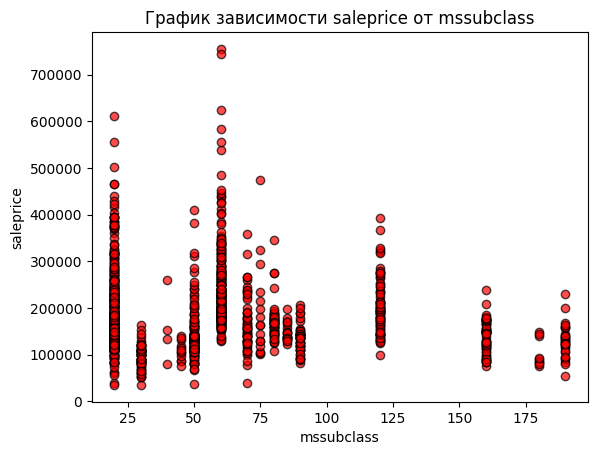

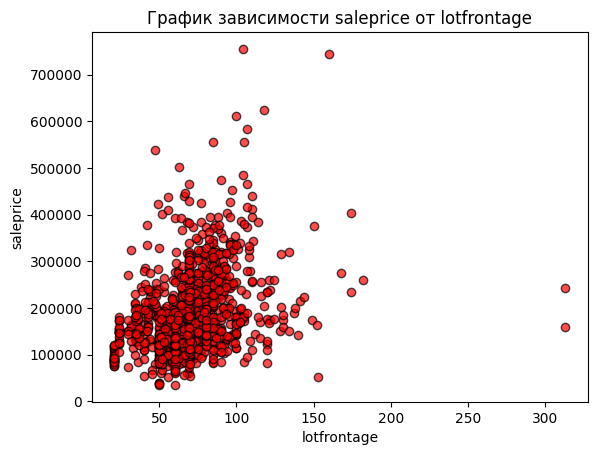

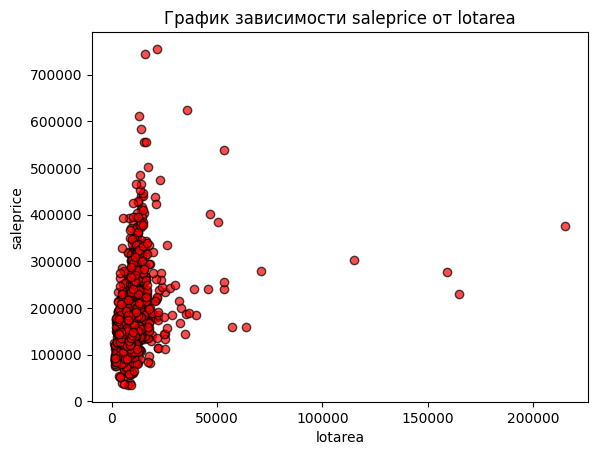

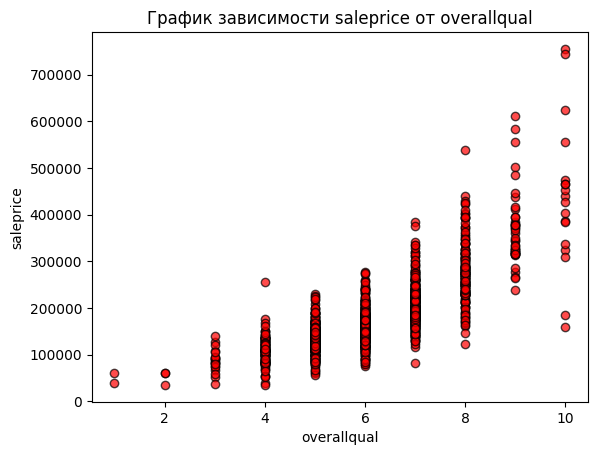

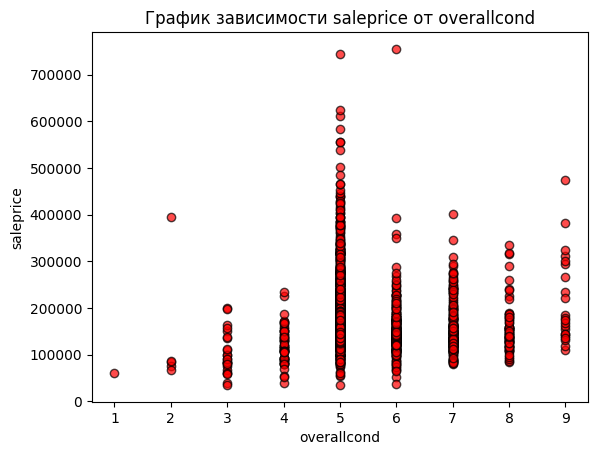

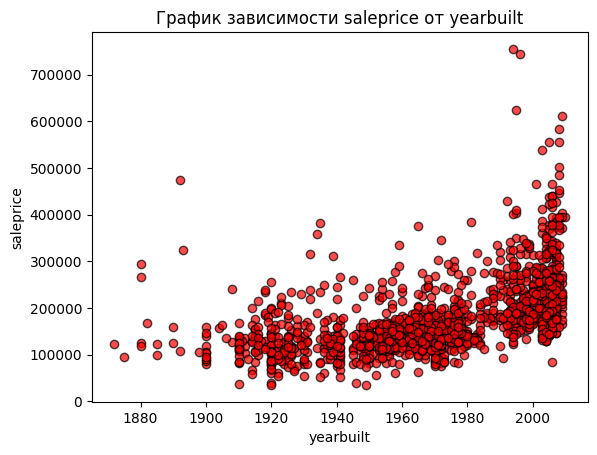

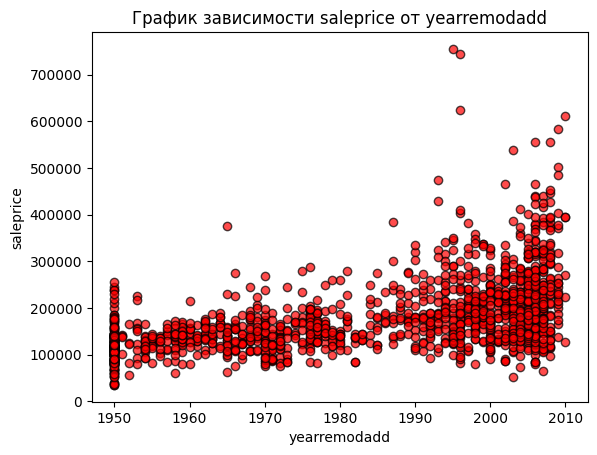

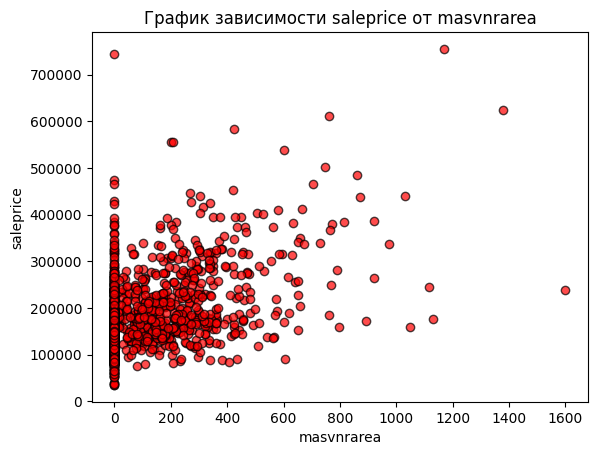

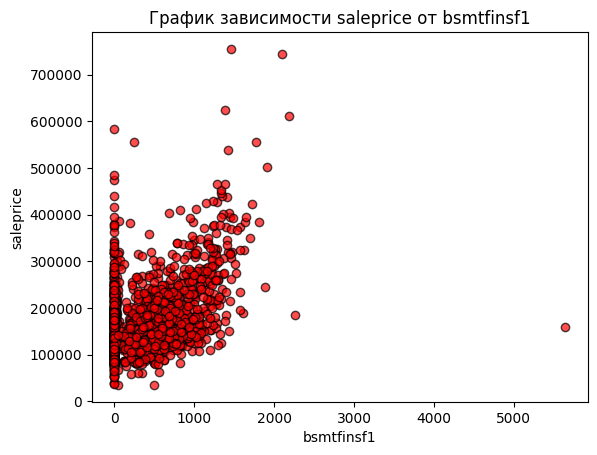

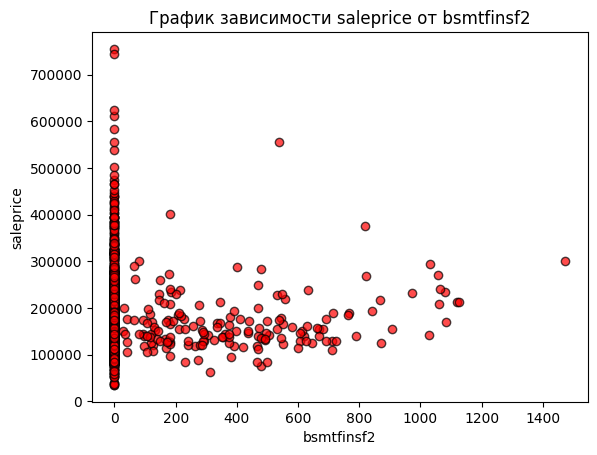

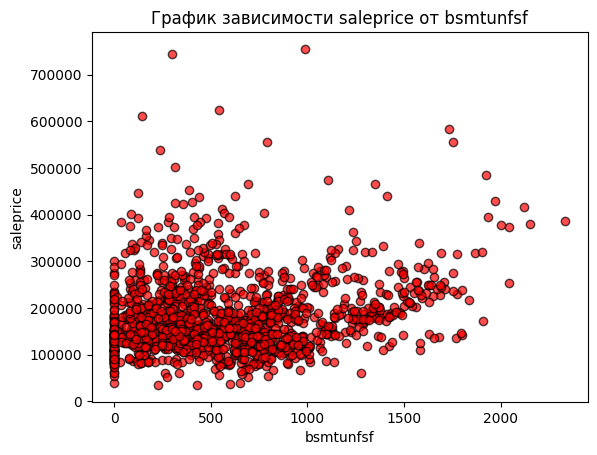

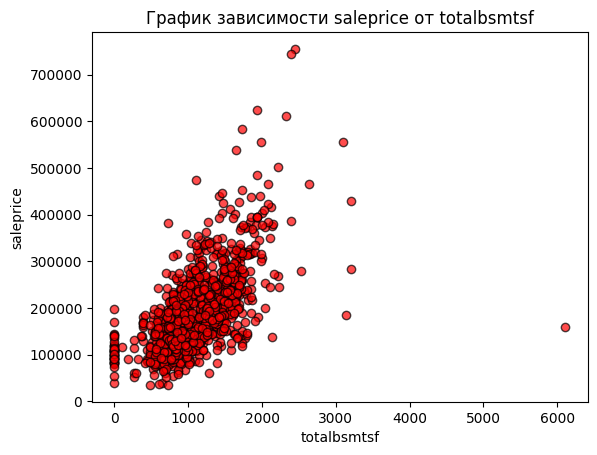

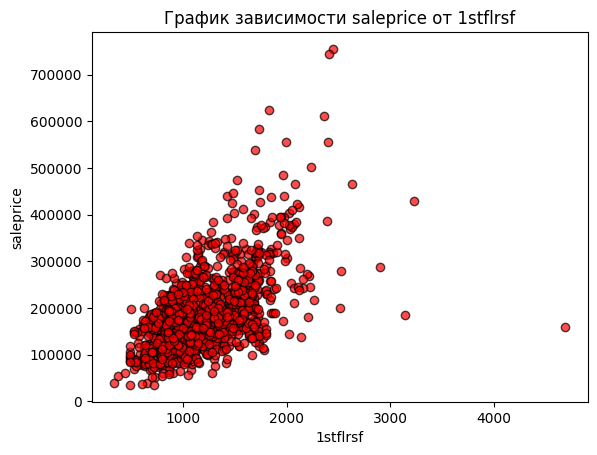

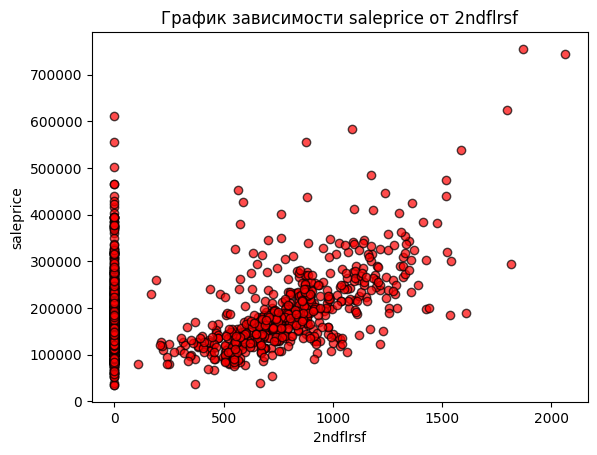

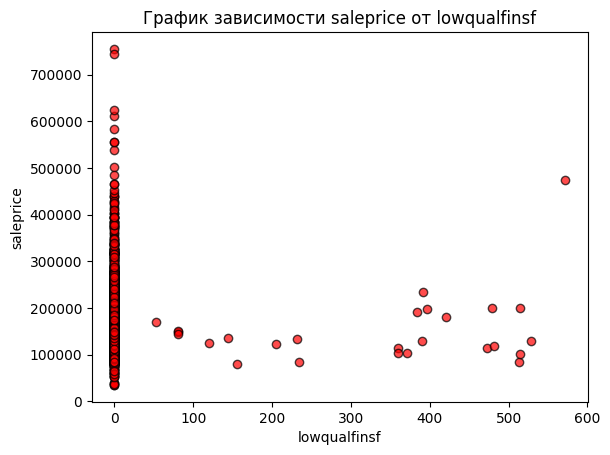

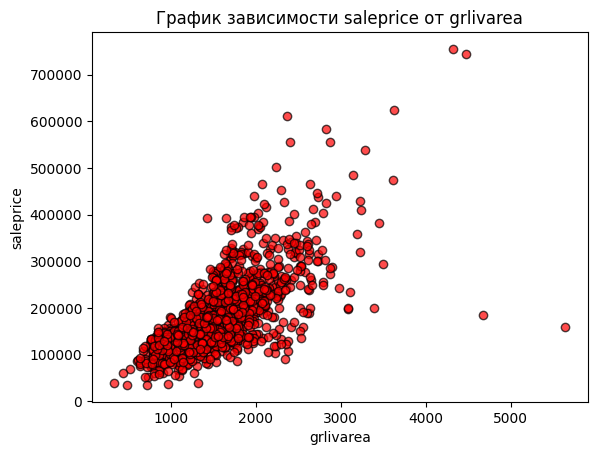

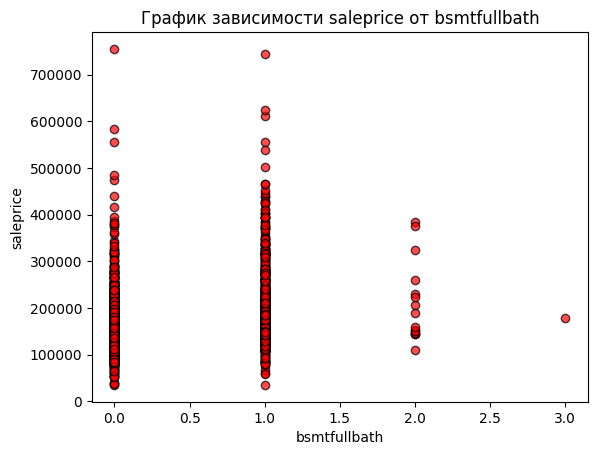

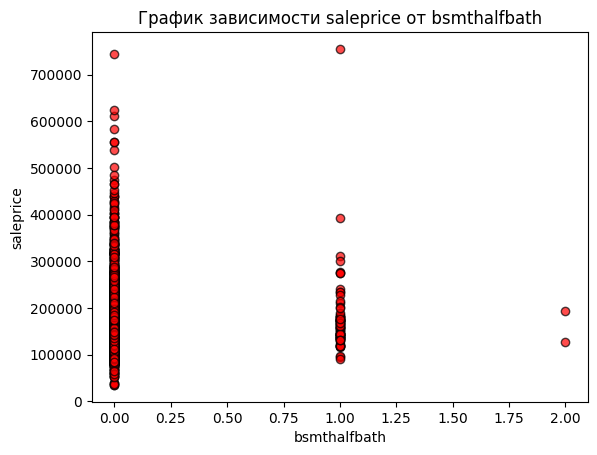

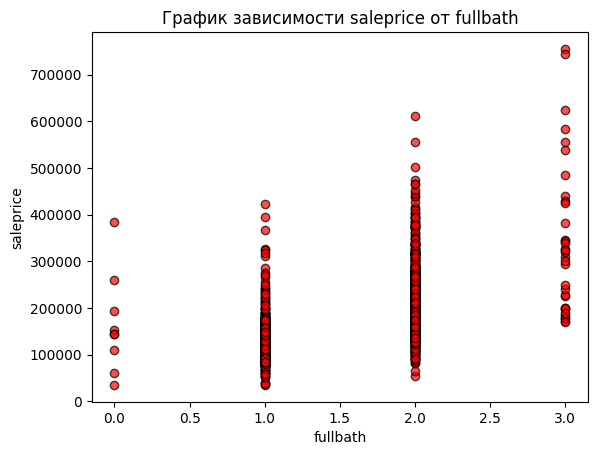

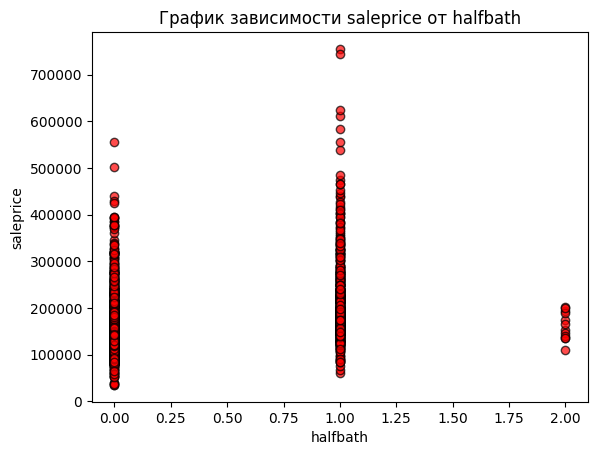

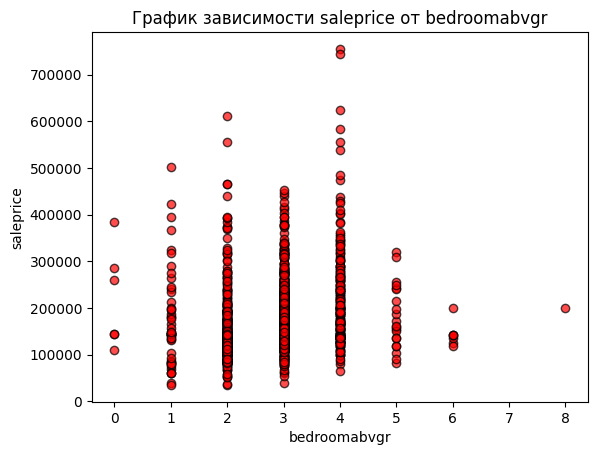

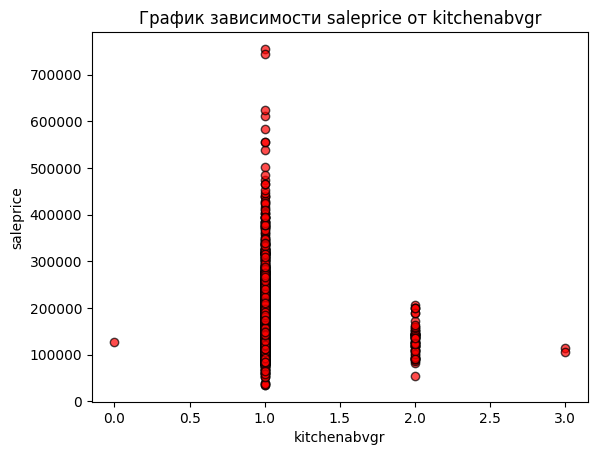

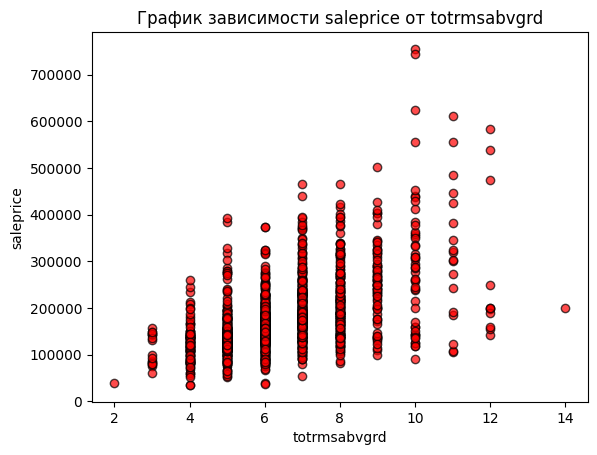

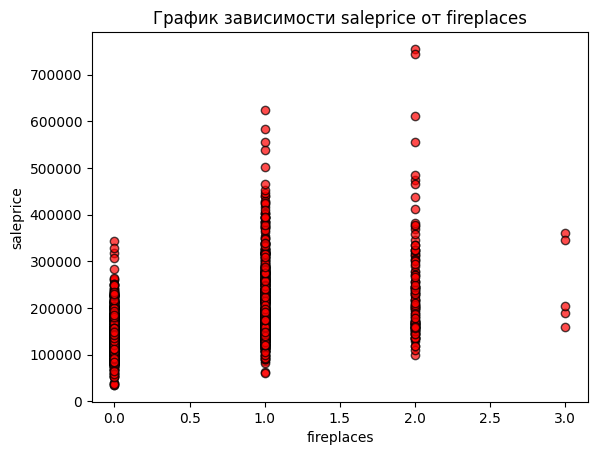

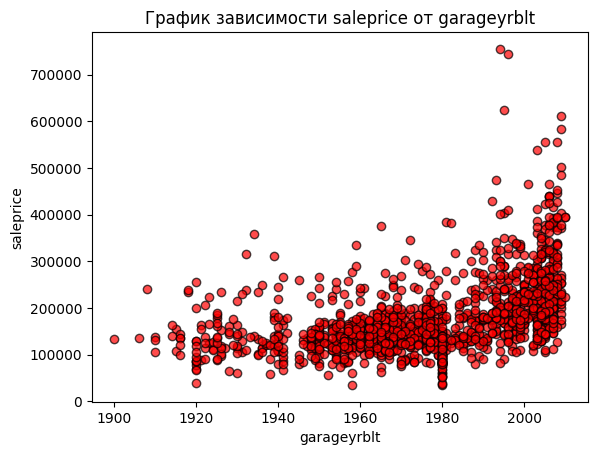

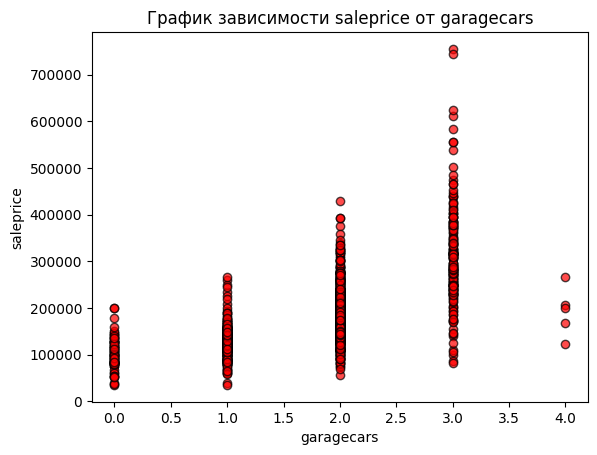

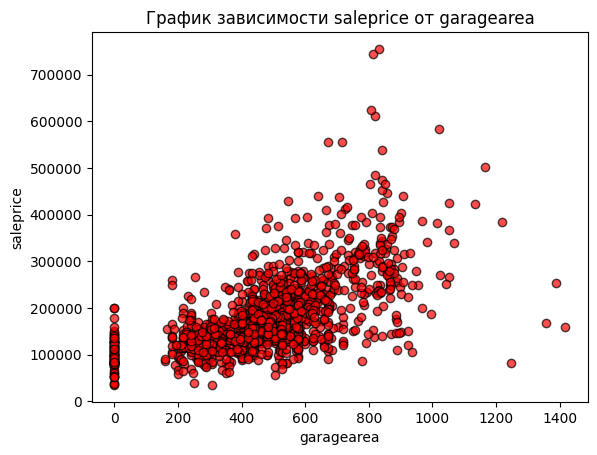

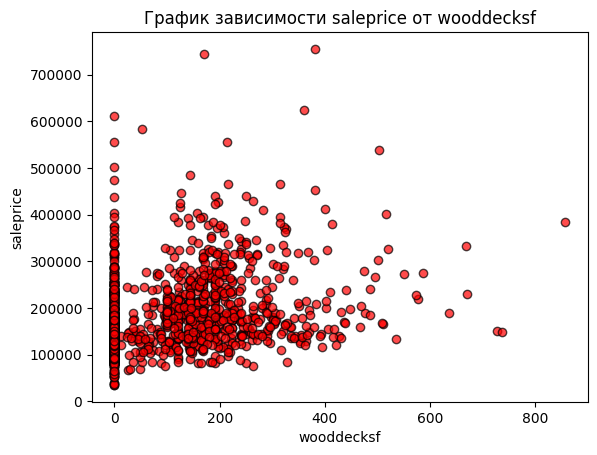

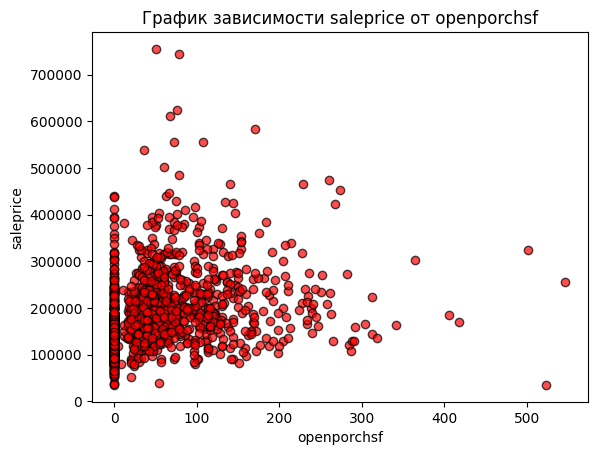

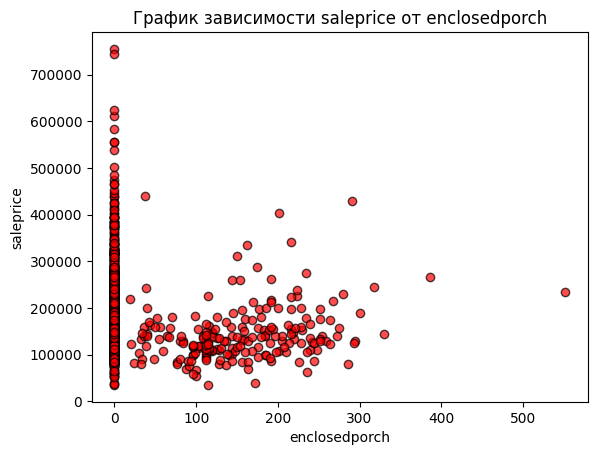

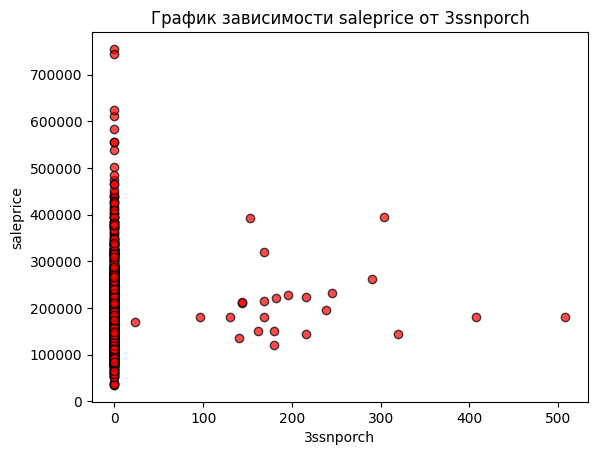

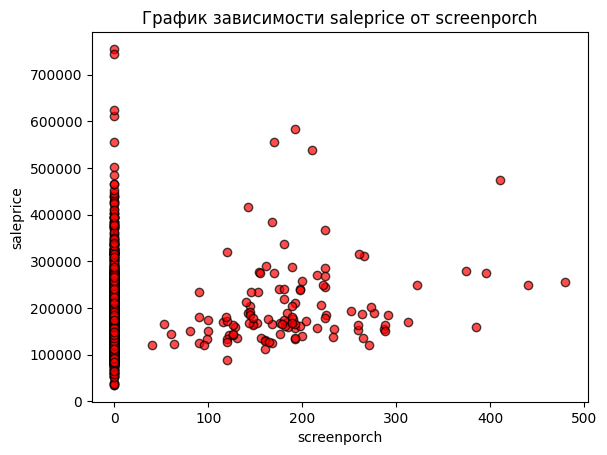

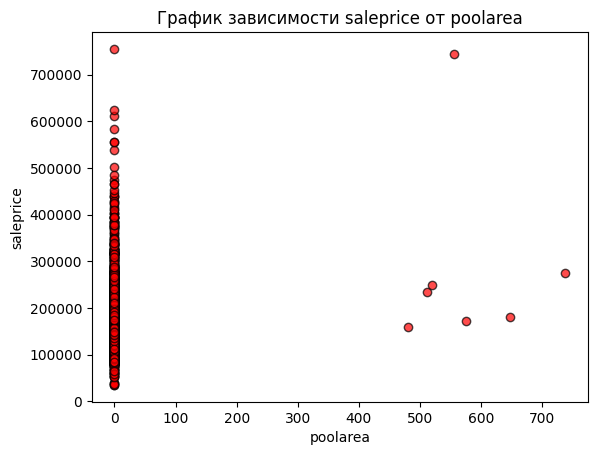

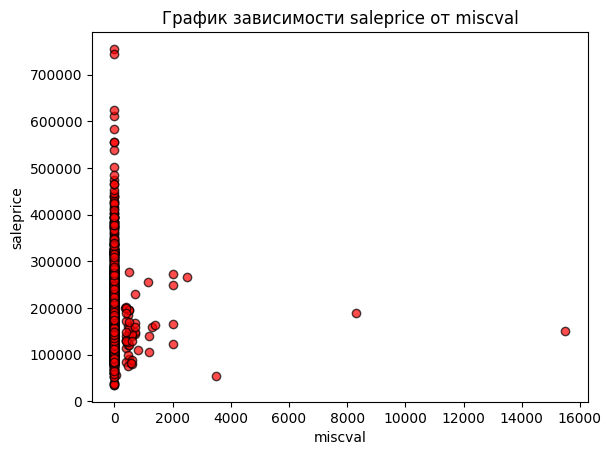

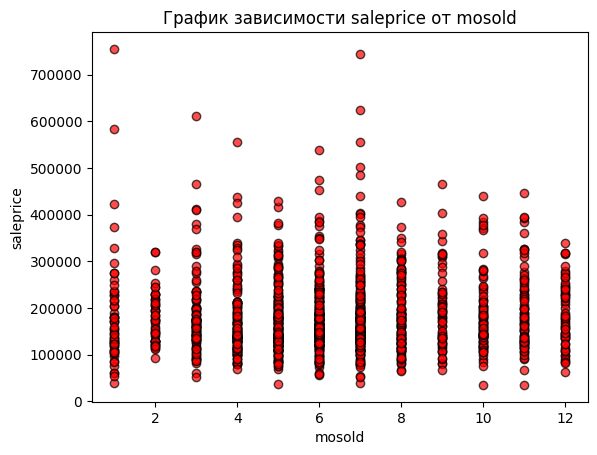

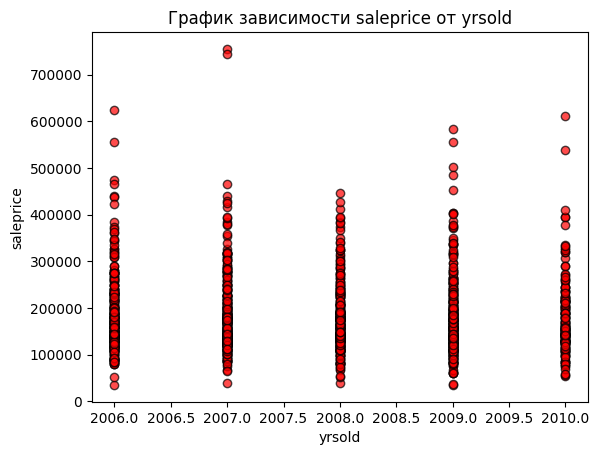

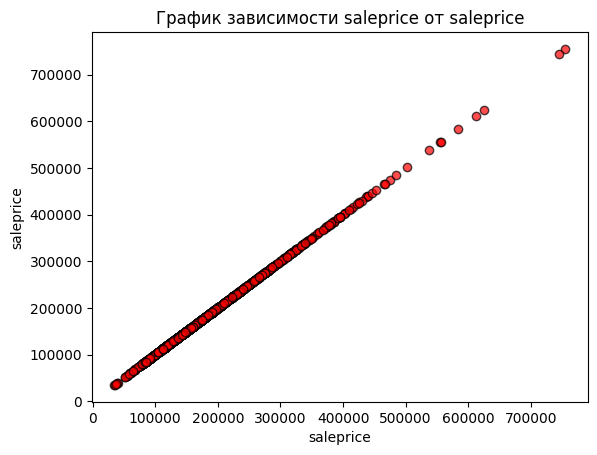

In [ ]:
for col in num_columns_train:
  plt.scatter(x=train_cleaned[col], y=train_cleaned['saleprice'], alpha=0.7,c='Red', edgecolors='Black')
  plt.title(f'График зависимости saleprice от {col}')
  plt.xlabel(f'{col}')
  plt.ylabel('saleprice')
  plt.show()

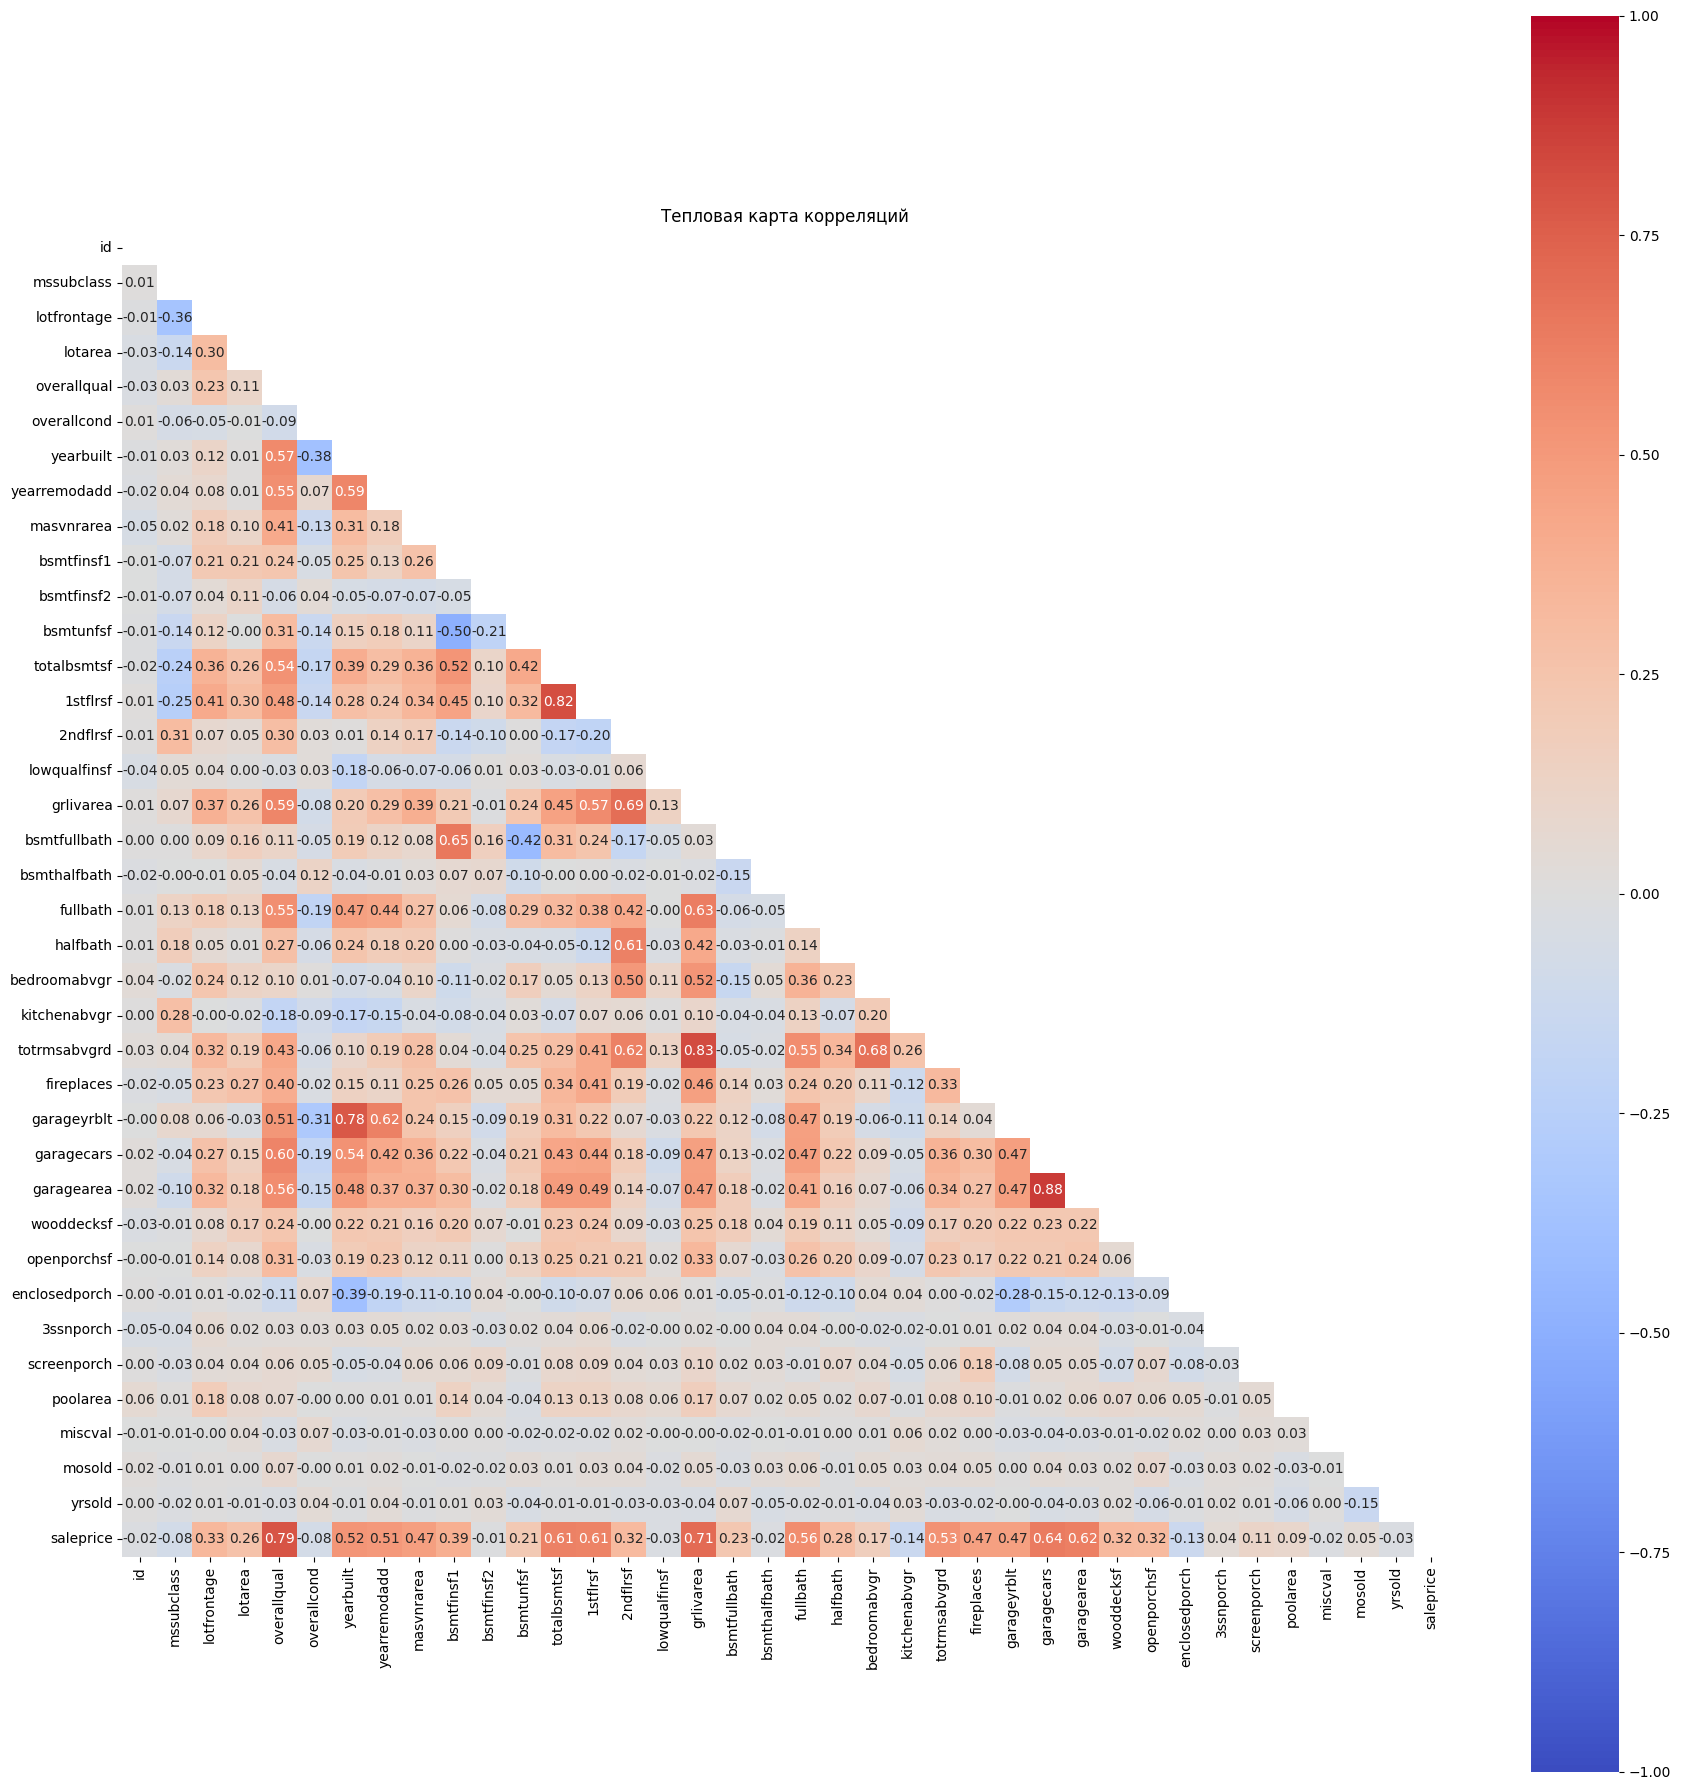

In [ ]:
corr = train_cleaned[num_columns_train].corr()

plt.figure(figsize=(18,18))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,mask=np.triu(corr),square=True)
plt.title('Тепловая карта корреляций')
plt.tight_layout()
plt.show()

**Вывод по EDA анализу:**
- Целевая переменная распределена нормально, есть аномальные значения ( особняки)
- Большинство признаков нелинейно зависимы , это означает что линейные модели не смогут хорошо работать с такиеми данными
- Есть коллинеарность между признаками garagecars и garagearea равная 0.88,придется удалить признак garagearea, так как он менее зависим с целевой переменной

In [ ]:
train_cleaned.drop(columns='garagearea')
test_cleaned.drop(columns='garagearea')

,id,mssubclass,mszoning,lotfrontage,lotarea,street,lotshape,landcontour,utilities,lotconfig,...,openporchsf,enclosedporch,3ssnporch,screenporch,poolarea,miscval,mosold,yrsold,saletype,salecondition
0,1461,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,120,0,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,Corner,...,36,0,0,0,0,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,Inside,...,34,0,0,0,0,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,IR1,Lvl,AllPub,Inside,...,36,0,0,0,0,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,IR1,HLS,AllPub,Inside,...,82,0,0,144,0,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,Reg,Lvl,AllPub,Inside,...,24,0,0,0,0,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,Reg,Lvl,AllPub,Inside,...,32,0,0,0,0,700,7,2006,WD,Normal


## Обучение модели

Для начала разделим данные на тренировочную и валидационную выборки, протестируем базовую модель LinearRegression

In [ ]:
train_cleaned[num_columns_train]

,id,mssubclass,lotfrontage,lotarea,overallqual,overallcond,yearbuilt,yearremodadd,masvnrarea,bsmtfinsf1,...,wooddecksf,openporchsf,enclosedporch,3ssnporch,screenporch,poolarea,miscval,mosold,yrsold,saleprice
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,61,0,0,0,0,0,2,2008,208500
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,298,0,0,0,0,0,0,5,2007,181500
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,42,0,0,0,0,0,9,2008,223500
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,35,272,0,0,0,0,2,2006,140000
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,62.0,7917,6,5,1999,2000,0.0,0,...,0,40,0,0,0,0,0,8,2007,175000
1456,1457,20,85.0,13175,6,6,1978,1988,119.0,790,...,349,0,0,0,0,0,0,2,2010,210000
1457,1458,70,66.0,9042,7,9,1941,2006,0.0,275,...,0,60,0,0,0,0,2500,5,2010,266500
1458,1459,20,68.0,9717,5,6,1950,1996,0.0,49,...,366,0,112,0,0,0,0,4,2010,142125


In [ ]:
from sklearn.model_selection import train_test_split

X = train_cleaned.drop(columns=['id','saleprice'])
y = train_cleaned['saleprice']

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Закодируем порядковые, числовые и категориальные признаки

In [ ]:
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,StandardScaler

ordenal_col = ['overallqual','overallcond']

categories_list = [[i for i in range(1,11)]] * len(ordenal_col)

encoder = OrdinalEncoder(categories=categories_list)

In [ ]:
X_train[ordenal_col] = encoder.fit_transform(X_train[ordenal_col])
X_test[ordenal_col] = encoder.transform(X_test[ordenal_col])

In [ ]:
num_col = X.select_dtypes(exclude='object').columns.tolist()
num_col.remove('overallqual')
num_col.remove('overallcond')
cat_col = X.select_dtypes(include='object').columns.tolist()

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore',sparse_output=False), cat_col),
        ('num',StandardScaler(),num_col)
    ],remainder='passthrough'
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

pipeline.fit(X_train,y_train)

y_pred_lr = pipeline.predict(X_test)
print(f'RMSE: {root_mean_squared_error(y_test,y_pred_lr)}')
print(f'MAE: {mean_absolute_error(y_test,y_pred_lr)}')

RMSE: 29647.296526966766
MAE: 18428.907783824943


Наша базовая модель показала качество RMSE: 30623.875672764712
MAE: 19016.192322914874

Проверим качество работы XGBoost модели

In [ ]:
! pip install xgboost -q

In [ ]:
from  xgboost import XGBRegressor as xgb

X = train_cleaned.drop(columns=['id','saleprice'])
y = train_cleaned['saleprice']

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(handle_unknown='ignore',sparse_output=False,drop='first'),cat_col)
    ],remainder='passthrough'
)

pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('xgb',xgb(
        n_estimators=500,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
    ))
])

pipeline.fit(X_train,y_train)

y_pred_xgb = pipeline.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [13, 27] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
print(f'RMSE: {root_mean_squared_error(y_test,y_pred_xgb)}')
print(f'MAE: {mean_absolute_error(y_test,y_pred_xgb)}')

RMSE: 25427.39453125
MAE: 16076.37109375


Попробуем подобрать гиперпараметры

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform


param_distributions = {
    'xgb__n_estimators': randint(100, 1000),
    'xgb__max_depth': randint(3, 10),
    'xgb__learning_rate': uniform(0.01, 0.2),
    'xgb__subsample': uniform(0.6, 0.4),
    'xgb__colsample_bytree': uniform(0.6, 0.4)
}


random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=0,
    n_jobs=-1,
    random_state=42
)


random_search.fit(X_train, y_train)


print("Лучшие параметры:", random_search.best_params_)
print("Лучшая оценка CV:", random_search.best_score_)


y_pred_xgb = random_search.predict(X_test)


Лучшие параметры: {'xgb__colsample_bytree': np.float64(0.632341330533086), 'xgb__learning_rate': np.float64(0.0839308912122809), 'xgb__max_depth': 3, 'xgb__n_estimators': 866, 'xgb__subsample': np.float64(0.9212559025519583)}
Лучшая оценка CV: -691750112.0


In [ ]:
print(f'RMSE: {root_mean_squared_error(y_test,y_pred_xgb)}')
print(f'MAE: {mean_absolute_error(y_test,y_pred_xgb)}')

RMSE: 25209.32421875
MAE: 15741.1162109375


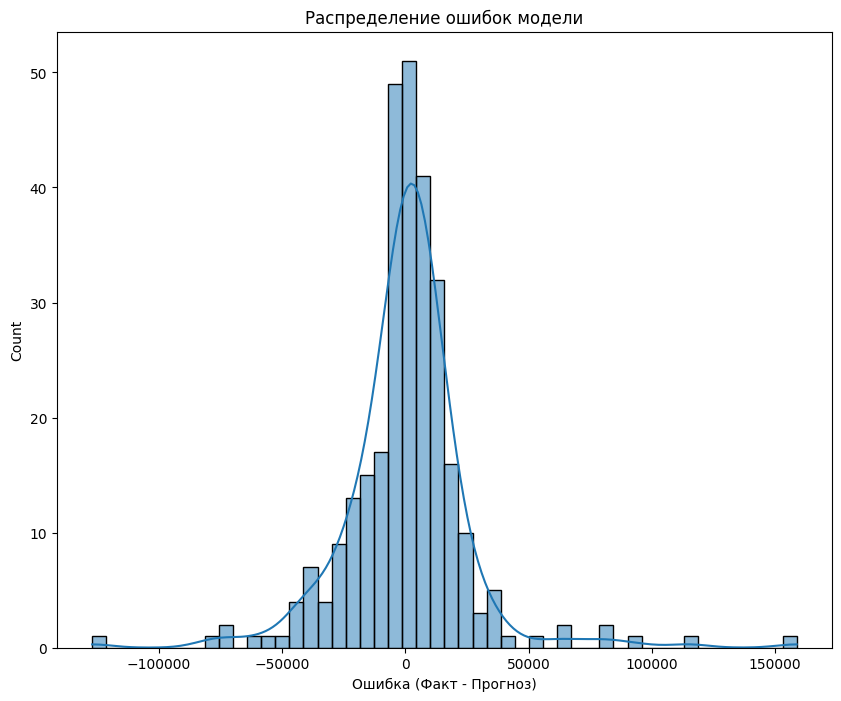

In [ ]:
errors = y_test - y_pred_xgb
plt.figure(figsize=(10,8))
sns.histplot(errors, bins=50, kde=True)
plt.title('Распределение ошибок модели')
plt.xlabel('Ошибка (Факт - Прогноз)')
plt.show()

## Интерпретация признаков

In [ ]:
model = random_search.best_estimator_.named_steps['xgb']
preprocessor = random_search.best_estimator_.named_steps['preprocessor']

importance = model.feature_importances_
feature_names = preprocessor.get_feature_names_out(X.columns)

df = pd.DataFrame({
    'importance': importance,
    'feature': feature_names
}).sort_values('importance',ascending=False)

/tmp/ipykernel_10731/1421637751.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.head(20), x='importance', y='feature', palette='viridis')


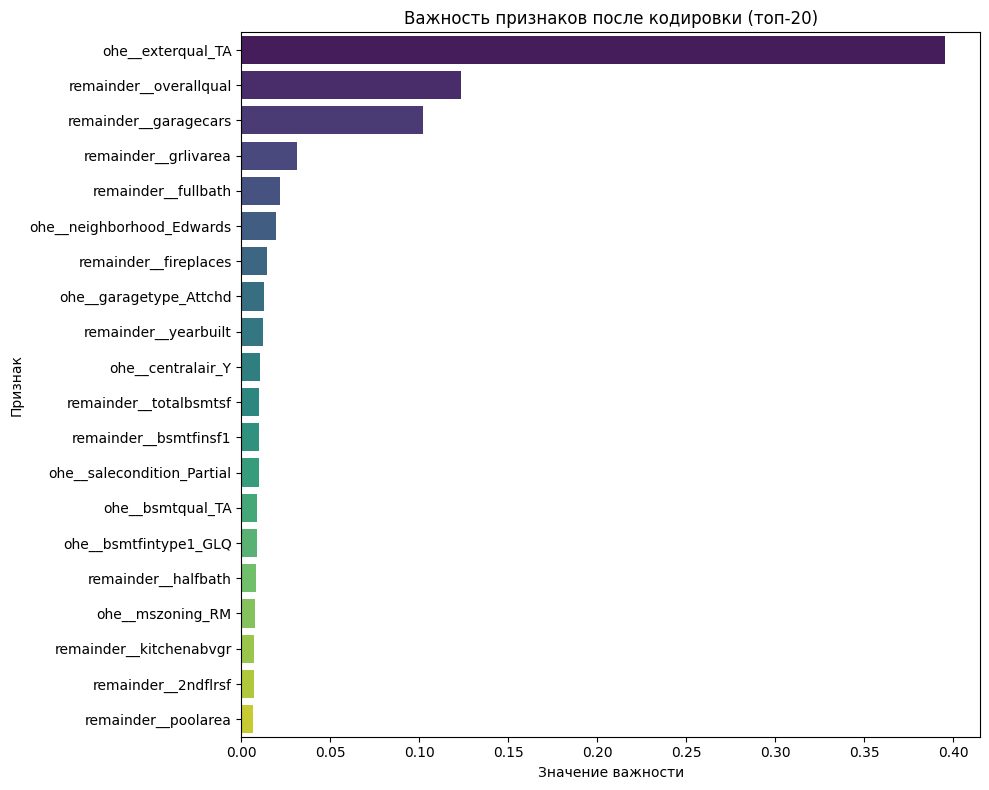

In [ ]:
plt.figure(figsize=(10,8))
sns.barplot(data=df.head(20), x='importance', y='feature', palette='viridis')
plt.title('Важность признаков после кодировки (топ‑20)')
plt.xlabel('Значение важности')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

In [ ]:
select_features = df[df['importance'] >= 0.005]['feature'].tolist()

In [ ]:
x_encoded = preprocessor.transform(X_train)
x_encoded_df = pd.DataFrame(
    x_encoded,
    columns=feature_names
)


In [ ]:
x_selected = x_encoded_df[select_features]

In [ ]:
select_features

['ohe__exterqual_TA',
 'remainder__overallqual',
 'remainder__garagecars',
 'remainder__grlivarea',
 'remainder__fullbath',
 'ohe__neighborhood_Edwards',
 'remainder__fireplaces',
 'ohe__garagetype_Attchd',
 'remainder__yearbuilt',
 'ohe__centralair_Y',
 'remainder__totalbsmtsf',
 'remainder__bsmtfinsf1',
 'ohe__salecondition_Partial',
 'ohe__bsmtqual_TA',
 'ohe__bsmtfintype1_GLQ',
 'remainder__halfbath',
 'ohe__mszoning_RM',
 'remainder__kitchenabvgr',
 'remainder__2ndflrsf',
 'remainder__poolarea',
 'remainder__yearremodadd',
 'remainder__1stflrsf',
 'ohe__saletype_New',
 'ohe__condition1_Feedr',
 'remainder__totrmsabvgrd',
 'ohe__mszoning_RL',
 'ohe__kitchenqual_TA']

In [ ]:
best_params = random_search.best_params_
xgb_params = {
    k.replace('xgb__', ''): v
    for k, v in best_params.items()
    if k.startswith('xgb__')
}


In [ ]:
x_selected.shape

(1168, 27)

In [ ]:
y_train.shape

(1168,)

In [ ]:
new_model = xgb(**xgb_params, random_state=42)
new_model.fit(x_selected, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=np.float64(0.632341330533086), device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None,
             learning_rate=np.float64(0.0839308912122809), max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=866, n_jobs=None,
             num_parallel_tree=None, ...)

In [ ]:

X_test_encoded = preprocessor.transform(X_test)
X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=preprocessor.get_feature_names_out(X_test.columns)
)


X_test_selected = X_test_encoded_df[select_features]


In [ ]:
y_pred = new_model.predict(X_test_selected)

In [ ]:
print(f'RMSE: {root_mean_squared_error(y_test,y_pred)}')
print(f'MAE: {mean_absolute_error(y_test,y_pred)}')

RMSE: 26400.490234375
MAE: 17835.732421875


**Вывод:** Лучшей моделью оказалась XGBRegressor с параметрами 'xgb__colsample_bytree': np.float64(0.632341330533086), 'xgb__learning_rate': np.float64(0.0839308912122809), 'xgb__max_depth': 3, 'xgb__n_estimators': 866, 'xgb__subsample': np.float64(0.9212559025519583). При попытке удалить неинформативные признаки, модель показывает качество хуже.Сделаем предсказание на тестовой выборке

In [ ]:
y_pred_finaly = random_search.predict(test_cleaned)

In [ ]:
submission = pd.DataFrame({
    'Id': test_cleaned['id'],
    'SalePrice': y_pred_finaly
})

In [ ]:
submission.to_csv('submission.csv', index=False)